## Introduction
In this script, gene expression counts and metadata of 460 vastus lateralis samples belonging to  232 participants who performed progressive resistance exercise training in 5 different studies were preprocessed to make them suitable for predictive modelling of hypertrophic responses to RT. While the gene expression counts are only from baseline samples ( before RT), the metadata contains percentage change in muscle mass from baseline to post-RT. Codes for initial metadata extraction is are saved in https://github.com/trainome/trainome-responder-analysis 

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dfply import *
import pydot, pyreadr
from scipy.stats import norm




Two functions are created; "categorize_by_group" and  "process_metadata". The former categorises the hypertrophic response (measured as percentage muscle change "pct_muscle_change") of particpants into "High_responder", "Average responder", and "No_responders" while the latter loads the individual RDS file for each study, adds the sequencing depth and the columns needed for predictive modelling

In [2]:

def categorize_by_group(df):
    """
    Categorizes participants into response levels within each 'condition' and 'volume' group.
    Adds a new column 'category' to the DataFrame.
    
    - High_responder: pct_muscle_change >= 90th percentile of the group
    - No_responder: pct_muscle_change < 1
    - Average_responder: all others
    """
    def label_group(group):
        high_threshold = np.percentile(group["pct_muscle_change"], 90)
        conditions = [
            group["pct_muscle_change"] >= high_threshold,
            group["pct_muscle_change"] < 1
        ]
        choices = ["High_responder", "No_responder"]
        group["category"] = np.select(conditions, choices, default="Average_responder")
        return group

    return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)



In [3]:
# A function to load the metadata of the different studies and the required columns
def process_metadata(filepath,  sequencing_depth):
    """
    Load and process metadata from an RDS file.

    Parameters:
        filepath (str): Path to the RDS file.
        category_function (callable): Function to categorize participants based on muscle change.
        sequencing_depth (float): Sequencing depth of each study, calculated in a previous analysis.

    Returns:
        pd.DataFrame: Processed metadata.
    """
    # Load the RDS file
    data = pyreadr.read_r(filepath)[None]

    # apply the  categorize_by_group functiomn
    data = categorize_by_group(data)

    # Add sequencing depth as a new column
    # This is calculated from the sequencing data
    data["sequencing_depth"] = sequencing_depth

    # Select relevant columns
    selected_columns = [
        "study", "participant", "sex", "seq_sample_id", "age", "BMI",
        "pct_muscle_change",  "category", "volume",
        "condition", "sequencing_depth"
    ]
    return data[selected_columns]


## COPD METADATA
Results from the COPD study published at https://translational-medicine.biomedcentral.com/articles/10.1186/s12967-021-02969-1 

In [4]:
# COPD metadata
copd_metadata = process_metadata("./COPD/copd_metadata.RDS", 1.2)
copd_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_38732\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,copd,FP102,female,X102PreExcVLR12,65.8,36.6,-1.98,No_responder,3.0,RM30,1.2
1,copd,FP102,female,X102PreExcVLR12,65.8,36.6,17.24,High_responder,3.0,RM10,1.2
2,copd,FP103,male,X103PreExcVLR23,70.9,28.5,6.81,Average_responder,3.0,RM10,1.2
3,copd,FP103,male,X103PreExcVLR23,70.9,28.5,14.01,Average_responder,3.0,RM30,1.2
4,copd,FP105,female,X105PreExcVLR38,67.0,24.6,13.87,Average_responder,3.0,RM30,1.2
...,...,...,...,...,...,...,...,...,...,...,...
98,copd,FP246,female,X246PreExcVLR518,64.3,22.4,6.10,Average_responder,3.0,RM10,1.2
99,copd,FP246,female,X246PreExcVLL519,64.3,22.4,3.88,Average_responder,3.0,RM30,1.2
100,copd,FP249,male,X249PreExcVLL529,63.6,22.0,4.32,Average_responder,3.0,RM30,1.2
101,copd,FP249,male,X249PreExcVLL529,63.6,22.0,3.34,Average_responder,3.0,RM10,1.2


<Axes: xlabel='category', ylabel='count'>

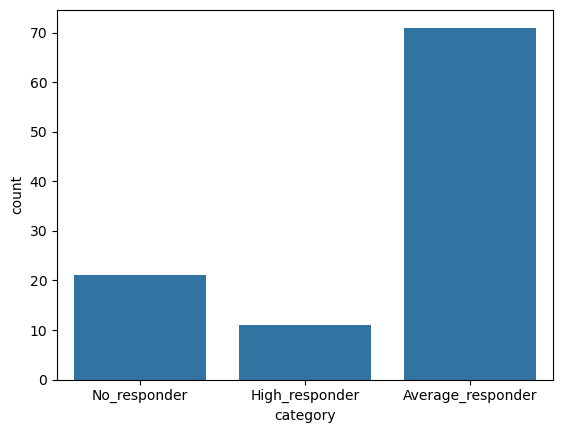

In [6]:
# Visualise distribution of samples in different response categories
sns.countplot(x =copd_metadata["category"])

(array([ 1.,  0.,  4., 12., 10., 31., 18., 13., 10.,  4.]),
 array([-16.38 , -12.363,  -8.346,  -4.329,  -0.312,   3.705,   7.722,
         11.739,  15.756,  19.773,  23.79 ]),
 <BarContainer object of 10 artists>)

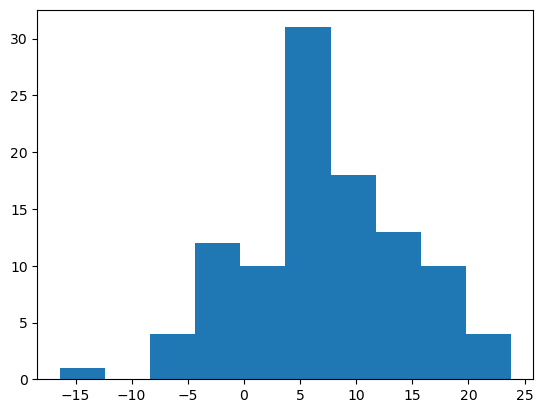

In [7]:
# Visualise percentage muscle change across participants
plt.hist(copd_metadata["pct_muscle_change"])

## ContraTRAIN metadata
Study details are registered in  [ClinicalTrials.gov ID: NCT03795025](https://clinicaltrials.gov/study/NCT03795025) 

In [8]:
contratrain_metadata = process_metadata("./ContraTrain/Contratrain_metadata.RDS", 4.03)

contratrain_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_38732\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,ct,FP1,female,X1.subj1sample1,21.0,28.6,3.78,Average_responder,0.0,RM10,4.03
1,ct,FP1,female,X2.subj1sample6,21.0,28.6,12.98,Average_responder,3.0,RM10,4.03
2,ct,FP2,male,X43.subj2sample4,24.0,31.2,9.88,Average_responder,3.0,RM10,4.03
3,ct,FP2,male,X44.subj2sample6,24.0,31.2,9.23,Average_responder,6.0,RM10,4.03
4,ct,FP3,female,X75.subj3sample5,23.0,22.5,17.03,Average_responder,6.0,RM10,4.03
...,...,...,...,...,...,...,...,...,...,...,...
59,ct,FP43,female,X108.subj43sample3,24.0,40.1,-1.62,No_responder,0.0,RM10,4.03
60,ct,FP44,female,X113.subj44sample4,30.0,24.6,10.30,Average_responder,3.0,RM10,4.03
61,ct,FP45,female,X116.subj45sample4,20.0,26.2,2.46,Average_responder,3.0,RM10,4.03
62,ct,FP46,female,X121.subj46sample7,22.0,22.9,3.90,Average_responder,0.0,RM10,4.03


<Axes: xlabel='category', ylabel='count'>

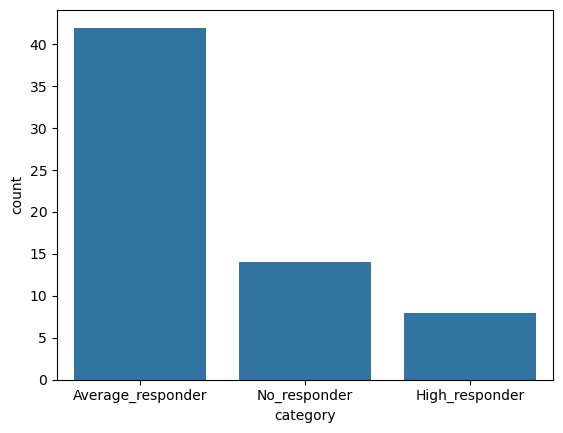

In [9]:
sns.countplot(x =contratrain_metadata["category"])

(array([ 4., 16., 13., 12., 13.,  2.,  3.,  0.,  0.,  1.]),
 array([-7.17 , -2.268,  2.634,  7.536, 12.438, 17.34 , 22.242, 27.144,
        32.046, 36.948, 41.85 ]),
 <BarContainer object of 10 artists>)

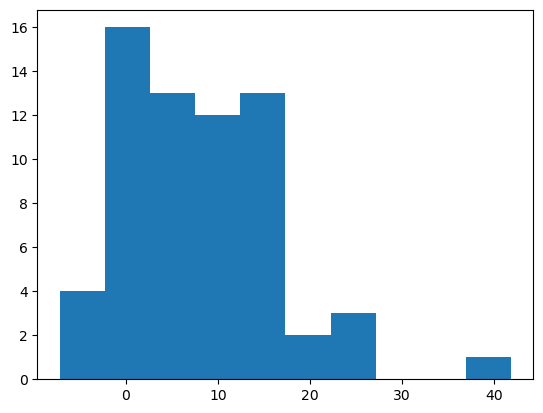

In [10]:
plt.hist(contratrain_metadata["pct_muscle_change"])

## Alpha and Omega 
Study details are contained in  [ClinicalTrials.gov ID:NCT04279951](https://clinicaltrials.gov/study/NCT04279951) 

In [11]:
AO_metadata = process_metadata("./Alpha_Omega/Alpha_Omega_metadata.RDS", 2.35)
AO_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_38732\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,Alpha/Omega,516,male,s104,46.0,29.0,18.75,Average_responder,3.0,RM10,2.35
1,Alpha/Omega,517,male,s112,53.0,30.3,12.66,Average_responder,3.0,RM10,2.35
2,Alpha/Omega,503,male,s13,46.0,25.3,50.37,High_responder,3.0,RM10,2.35
3,Alpha/Omega,520,male,s130,58.0,29.9,8.62,Average_responder,3.0,RM10,2.35
4,Alpha/Omega,521,female,s136,48.0,18.4,33.69,High_responder,3.0,RM10,2.35
...,...,...,...,...,...,...,...,...,...,...,...
161,Alpha/Omega,683,female,s874,35.0,29.3,2.60,Average_responder,3.0,RM30,2.35
162,Alpha/Omega,684,female,s875,48.0,31.6,24.79,Average_responder,3.0,RM30,2.35
163,Alpha/Omega,692,male,s883,58.0,23.9,43.34,High_responder,3.0,RM30,2.35
164,Alpha/Omega,693,female,s891,54.0,21.8,21.82,Average_responder,3.0,RM30,2.35


<Axes: xlabel='category', ylabel='count'>

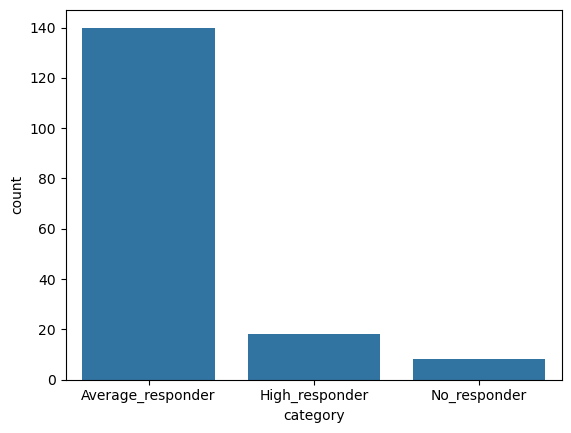

In [12]:
sns.countplot(x =AO_metadata["category"])

(array([ 6., 16., 46., 36., 31., 15.,  9.,  3.,  2.,  2.]),
 array([-8.28 , -1.878,  4.524, 10.926, 17.328, 23.73 , 30.132, 36.534,
        42.936, 49.338, 55.74 ]),
 <BarContainer object of 10 artists>)

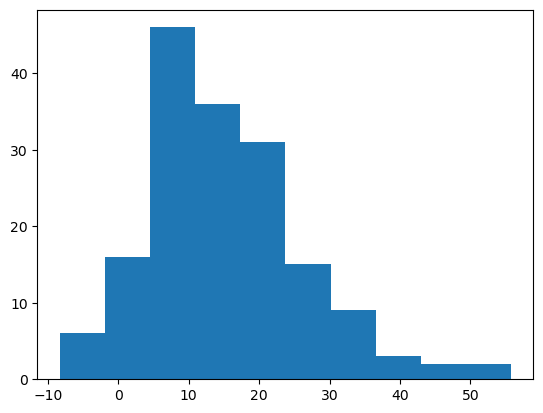

In [13]:
plt.hist(AO_metadata["pct_muscle_change"])

## Volume 
Results of primary study published here https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-020-03866-y 

In [14]:
Volume_metadata = process_metadata("./Volume/Volume_metadata.RDS", 1.51)
Volume_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_38732\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,vol,FP11,male,FP11w0R,22.3,23.6,0.18,No_responder,3.0,RM10,1.51
1,vol,FP11,male,FP11w0L,22.3,23.6,-1.53,No_responder,1.0,RM10,1.51
2,vol,FP12,female,FP12w0R,21.3,22.8,-0.60,No_responder,3.0,RM10,1.51
3,vol,FP12,female,FP12w0L,21.3,22.8,0.68,No_responder,1.0,RM10,1.51
4,vol,FP13,male,FP13w0L,22.7,19.8,12.12,High_responder,3.0,RM10,1.51
5,vol,FP13,male,FP13w0R,22.7,19.8,6.72,Average_responder,1.0,RM10,1.51
6,vol,FP14,female,FP14w0R,22.1,24.1,6.45,Average_responder,3.0,RM10,1.51
7,vol,FP14,female,FP14w0L,22.1,24.1,6.16,Average_responder,1.0,RM10,1.51
8,vol,FP15,male,FP15w0R,23.6,21.1,5.26,Average_responder,3.0,RM10,1.51
9,vol,FP15,male,FP15w0L,23.6,21.1,2.68,Average_responder,1.0,RM10,1.51


<Axes: xlabel='category', ylabel='count'>

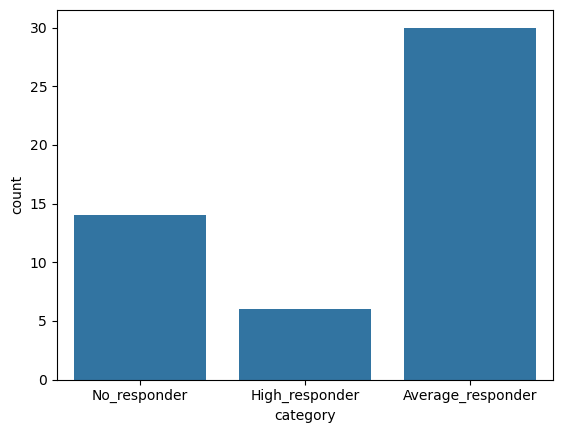

In [15]:
sns.countplot(x =Volume_metadata["category"])

(array([5., 9., 7., 5., 4., 5., 8., 3., 1., 3.]),
 array([-2.16, -0.72,  0.72,  2.16,  3.6 ,  5.04,  6.48,  7.92,  9.36,
        10.8 , 12.24]),
 <BarContainer object of 10 artists>)

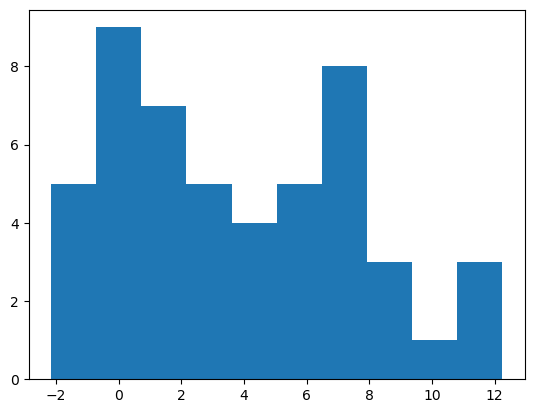

In [16]:
plt.hist(Volume_metadata["pct_muscle_change"])

## ReLief
Study details are are registered in [ClinicalTrials.gov ID:NCT05063279](https://clinicaltrials.gov/study/NCT05063279)

In [17]:
Relief_metadata = process_metadata("./Relief/Relief_metadata.RDS", 2.33)
Relief_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_38732\580225714.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["condition", "volume"], group_keys=False).apply(label_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,category,volume,condition,sequencing_depth
0,ReLiEf,3003,male,R_8,27.0,25.9,33.45,High_responder,1.0,RM10,2.33
1,ReLiEf,3006,male,R_18,21.0,24.5,4.39,Average_responder,1.0,RM10,2.33
2,ReLiEf,3007,male,R_25,73.0,24.2,-16.01,No_responder,1.0,RM10,2.33
3,ReLiEf,3009,male,R_30,79.0,26.0,33.09,High_responder,3.0,RM10,2.33
4,ReLiEf,3009,male,R_34,79.0,26.0,3.29,Average_responder,1.0,RM10,2.33
...,...,...,...,...,...,...,...,...,...,...,...
73,ReLiEf,3075,male,R_321,81.0,22.6,8.58,Average_responder,3.0,RM10,2.33
74,ReLiEf,3079,male,R_331,23.0,28.7,23.89,Average_responder,3.0,RM10,2.33
75,ReLiEf,3083,male,R_342,72.0,29.4,18.51,Average_responder,1.0,RM10,2.33
76,ReLiEf,3084,male,R_348,80.0,20.2,-6.90,No_responder,3.0,RM10,2.33


<Axes: xlabel='category', ylabel='count'>

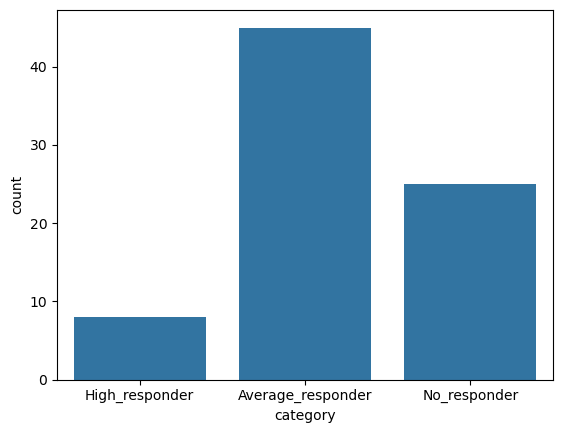

In [18]:
sns.countplot(x =Relief_metadata["category"])

(array([ 5.,  8., 16., 16., 19.,  7.,  4.,  2.,  0.,  1.]),
 array([-21.53 , -13.498,  -5.466,   2.566,  10.598,  18.63 ,  26.662,
         34.694,  42.726,  50.758,  58.79 ]),
 <BarContainer object of 10 artists>)

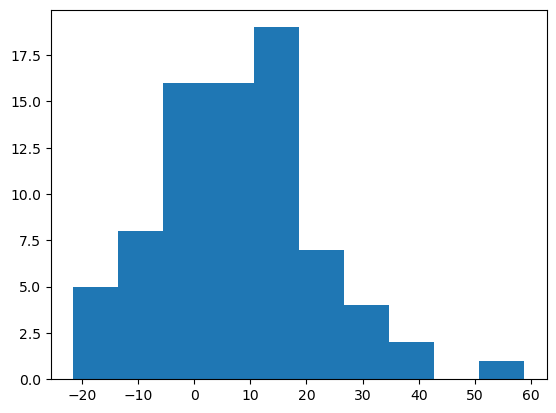

In [19]:
plt.hist(Relief_metadata["pct_muscle_change"])

In [20]:
# Concatenate all metadata
full_metadata = pd.concat([AO_metadata, contratrain_metadata, copd_metadata,Relief_metadata, Volume_metadata], ignore_index = True)
# distinguish each participant from the others in different studies as some participant ids are repeated across studies
full_metadata["participant"] = full_metadata["study"] + "_" + full_metadata["participant"]

full_metadata = full_metadata[["participant","seq_sample_id", "age", "BMI", "sex",   "category",  "sequencing_depth", "volume"]]
# ensure volume is integer
full_metadata["volume"] = full_metadata["volume"].astype(int)
full_metadata

,participant,seq_sample_id,age,BMI,sex,category,sequencing_depth,volume
0,Alpha/Omega_516,s104,46.0,29.0,male,Average_responder,2.35,3
1,Alpha/Omega_517,s112,53.0,30.3,male,Average_responder,2.35,3
2,Alpha/Omega_503,s13,46.0,25.3,male,High_responder,2.35,3
3,Alpha/Omega_520,s130,58.0,29.9,male,Average_responder,2.35,3
4,Alpha/Omega_521,s136,48.0,18.4,female,High_responder,2.35,3
...,...,...,...,...,...,...,...,...
456,vol_FP6,FP6w0R,21.8,20.5,female,No_responder,1.51,1
457,vol_FP7,FP7w0L,21.2,28.2,male,High_responder,1.51,3
458,vol_FP7,FP7w0R,21.2,28.2,male,High_responder,1.51,1
459,vol_FP9,FP9w0R,20.6,21.2,male,Average_responder,1.51,3


<Axes: xlabel='category', ylabel='count'>

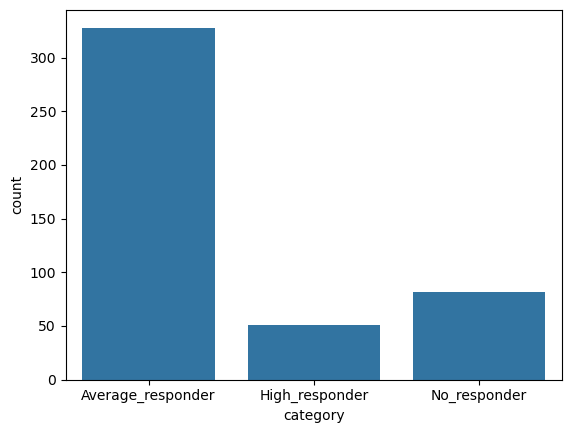

In [21]:
sns.countplot(x = full_metadata["category"])

## Load the different gene counts
These have been normalised by library size as shown in the [GitHub repository](https://github.com/trainome/trainome-responder-analysis/blob/main/R/gener_expression_PreExc.R)

In [22]:


def load_rds_dataframe(filepath):
    """
    Load a DataFrame from an RDS file using pyreadr.

    Parameters:
        filepath (str): Path to the RDS file.

    Returns:
        pd.DataFrame: The extracted DataFrame from the RDS file.
    """
    result = pyreadr.read_r(filepath)
    return result[None]

In [23]:
# Alpha_Omega data
AO_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_AO_counts.RDS")

#Contratrain data
Contratrain_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_contratrain_counts.RDS")

# COPD data
Copd_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_COPD_counts.RDS")

# Relief data
Relief_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_Relief_counts.RDS")

# Volume data
Volume_genecounts = load_rds_dataframe("./gene_extracts/cpm_normalised_PreExc_vol_counts.RDS")

# Merge all gene count datasets on the 'gene_name' column
datasets = [AO_genecounts, Contratrain_genecounts, Copd_genecounts, Relief_genecounts, Volume_genecounts]
full_genecounts = datasets[0]

for df in datasets[1:]:
    full_genecounts = full_genecounts.merge(df, on="gene_name")
#full_genecounts.to_csv("full_genecounts.csv", index = False)
# Reformat the merged DataFrame
full_genecounts = (
    full_genecounts
    .set_index("gene_name")
    .T
    .reset_index()
    .rename(columns={"index": "seq_sample_id"})
    .round(2)
)

full_genecounts


gene_name,seq_sample_id,TSPAN6,DPM1,SCYL3,CFH,FUCA2,GCLC,NFYA,NIPAL3,LAS1L,...,ENSG00000308270,ENSG00000309097,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533
0,s104,2.85,19.47,6.06,12.99,4.15,9.78,8.41,9.10,23.94,...,7.30,3.34,3.51,2.66,31.37,157.40,13.45,15.81,16.39,2.24
1,s112,4.25,19.76,6.39,19.20,5.70,17.68,10.84,9.19,17.68,...,9.82,1.52,3.50,2.66,15.78,184.27,12.59,30.12,23.76,3.25
2,s13,2.46,18.50,5.84,12.23,4.67,8.91,8.73,7.18,19.02,...,5.97,1.30,1.52,1.69,59.18,112.53,19.85,32.41,32.34,2.70
3,s130,2.30,16.77,8.36,15.13,3.07,8.56,9.33,5.08,25.74,...,2.42,1.83,6.24,3.66,50.90,174.12,23.37,32.45,29.37,2.70
4,s136,3.71,20.30,7.15,17.74,5.68,11.86,9.21,3.46,21.19,...,5.56,2.10,2.97,4.39,40.53,179.86,12.12,17.64,16.53,3.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,FP6w0R,6.57,30.72,8.41,22.26,4.81,12.66,11.25,14.89,22.27,...,13.60,2.58,4.64,7.15,675.39,143.34,3.45,5.61,4.61,4.41
284,FP7w0L,3.76,34.44,7.34,17.47,3.76,11.28,8.33,11.15,20.82,...,26.73,5.24,1.66,7.79,754.49,157.02,2.54,6.38,3.99,2.55
285,FP7w0R,4.51,33.87,5.79,18.75,3.78,10.84,7.31,10.97,20.96,...,22.30,4.51,2.79,7.19,721.26,156.08,5.11,10.87,5.40,1.82
286,FP9w0R,4.12,34.01,7.86,11.90,4.74,7.73,9.61,9.61,25.82,...,33.06,3.87,0.98,10.73,710.98,178.77,7.24,13.17,8.82,1.94


Merge the genes and metadata into one dataframe and encode the sex column as a dummy variable

In [24]:
# join the gene expression data and the metadata
df = ( full_metadata.merge(full_genecounts, on = "seq_sample_id")
       .sort_values(by = "seq_sample_id")
     )
df = pd.get_dummies(df, columns = ["sex"], dtype=int) # create dummy variable
df

,participant,seq_sample_id,age,BMI,category,sequencing_depth,volume,TSPAN6,DPM1,SCYL3,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
412,vol_FP11,FP11w0L,22.3,23.6,No_responder,1.51,1,3.85,30.23,8.50,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
411,vol_FP11,FP11w0R,22.3,23.6,No_responder,1.51,3,4.72,27.63,9.59,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
414,vol_FP12,FP12w0L,21.3,22.8,No_responder,1.51,1,5.48,32.51,6.23,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
413,vol_FP12,FP12w0R,21.3,22.8,No_responder,1.51,3,5.88,28.35,5.72,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
415,vol_FP13,FP13w0L,22.7,19.8,High_responder,1.51,3,5.59,34.57,4.74,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,Alpha/Omega_693,s891,54.0,21.8,Average_responder,2.35,3,3.94,18.93,7.06,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
165,Alpha/Omega_694,s903,42.0,27.3,High_responder,2.35,3,4.37,18.69,7.91,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
81,Alpha/Omega_694,s903,42.0,27.3,Average_responder,2.35,3,4.37,18.69,7.91,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
82,Alpha/Omega_515,s96,48.0,27.7,Average_responder,2.35,3,4.69,25.65,7.67,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


In [25]:
# How many of each responder category is present in the dataset
df["category"].value_counts()

category
Average_responder    328
No_responder          82
High_responder        51
Name: count, dtype: int64

In [26]:
df.to_csv("./dataset_for_classification_model.csv", index = False)